#MNIST IMAGE DATA CLASSIFICATION

#Problem Statement:
This assignment challenges students to construct and train a neural network to
accurately classify handwritten digits from the MNIST dataset. The goal is to
navigate through the preprocessing of image data, select an appropriate neural
network architecture, and apply optimization techniques to achieve high
classification accuracy.

#Introduction:
The MNIST dataset is a large database of handwritten digits commonly used for
training various image processing systems. The dataset contains 60,000 training
images and 10,000 testing images, each of which is a 28x28 pixel grayscale
image. The goal is to build a neural network model that can accurately classify
these images into one of the ten digit classes (0 through 9).

#Objectives:

Data Preprocessing: Prepare the MNIST dataset for training and testing the
neural network model. This includes normalization of image pixel values and
converting the output labels to a one-hot encoded format.


Model Development: Create a neural network model capable of classifying
28x28 pixel grayscale images of handwritten digits. The model should have an
input layer, one or more hidden layers, and an output layer.


Training: Train the neural network model using the preprocessed training data.
Utilize categorical cross-entropy as the loss function, stochastic gradient descent
as the optimizer, and track accuracy as a performance metric.


Evaluation: Evaluate the performance of the trained model using the testing
dataset, ensuring that the model generalizes well to unseen data.

Prediction: Implement functionality to make predictions on single images or
batches of images, returning the digit class with the highest probability.

Analysis: Analyze the results, understand the model's performance, and explore
ways to improve it if necessary.



#Challenges and Considerations:
Class Imbalance: Ensure that the dataset does not have a significant class
imbalance that could negatively affect the model’s performance. If imbalance is
present, strategies to mitigate its effects should be considered.


Model Complexity: Choose an appropriate model complexity that is capable of
learning from the data without overfitting. This may involve experimenting with
different numbers of layers and units, as well as regularization techniques.


Activation Functions: Use appropriate activation functions in the hidden layers
(ReLU is commonly used for image data) and softmax activation in the output
layer to convert logits to probabilities.

Evaluation Metrics: Focus on accuracy as the primary evaluation metric, but
also be open to exploring other metrics that could provide additional insights into
the model’s performance.


Hyperparameter Tuning: Experiment with different hyperparameters such as
learning rate, batch size, and number of epochs to optimize the model’s
performance.


Predictions and Interpretability: Provide clear and interpretable predictions,
ensuring that the output probabilities are well-calibrated and meaningful.

#IMPORTING LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import confusion_matrix, classification_report

#LOADING IMAGES AND FILES FROM DATA.

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
test_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  84, 185, 159, 151,  60,  36,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 222, 254, 254, 254, 254, 241, 198,
        198, 198, 198, 198, 198, 198, 198, 170,  52,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  67, 114,  72, 114, 163, 227, 254,
        225, 254, 254, 254, 250, 229, 254, 254, 140,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  17,  66,
         14,  67,  67,  67,  59,  21, 236, 254, 106,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  83, 253, 209,  18,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  22, 233, 255,  83,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 129, 254, 238,  44,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  59, 249, 254,  62,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0, 133, 254, 187,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   9, 205, 248,  58,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 126, 254, 182,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  75, 251, 240,  57,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         19, 221, 254, 166,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
        203, 254, 219,  35,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38,
        254, 254,  77,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  31, 224,
        254, 115,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 133, 254,
        254,  52,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

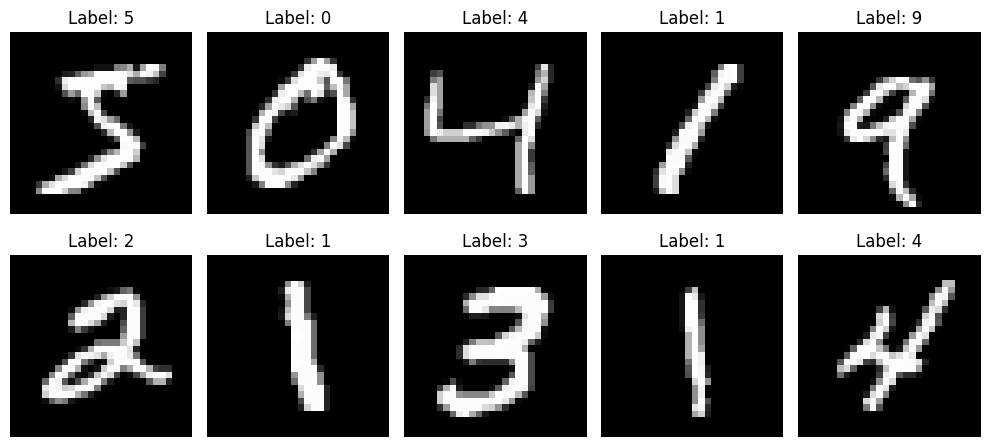

In [4]:
#Image plotting with labels

plt.figure(figsize=(10,5))
for i in range(10):
       plt.subplot(2,5,i+1)
       img=train_images[i]
       plt.imshow(img,cmap='gray')
       plt.title(f"Label: {train_labels[i]}")
       plt.axis('off')
       plt.tight_layout()

In [5]:
#Normalizing the data and bringing it in a range of 0 to 1

train_images=train_images.astype('float32')/255
test_images=test_images.astype('float32')/255

In [6]:
#Reshape the images

train_images=train_images.reshape((-1,28,28,1))
test_images=test_images.reshape((-1,28,28,1))

In [7]:
#Convert labels into categorical vartiable to prevent data from leakage.

train_labels_categorical=tf.keras.utils.to_categorical(train_labels)
test_labels_categorical=tf.keras.utils.to_categorical(test_labels)

In [8]:
#To check data distribution of each label

Unique, counts=np.unique(train_labels,return_counts=True)
for digit,count in zip(Unique,counts):
    print(f"Digit: {digit}, Count: {count}")

Digit: 0, Count: 5923
Digit: 1, Count: 6742
Digit: 2, Count: 5958
Digit: 3, Count: 6131
Digit: 4, Count: 5842
Digit: 5, Count: 5421
Digit: 6, Count: 5918
Digit: 7, Count: 6265
Digit: 8, Count: 5851
Digit: 9, Count: 5949


In [9]:
#Creating the sequential layer

data_augmentation=tf.keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10,0.10),
    layers.RandomContrast(0.1)
], name="data_augmentation")

Random rotation means that the image can be rotated +- of 0.15 (15% of360) in any direction.

Random zoom means that the image can be zoomed in and out 0.15 (15%)

Random translation means that the actual image can be shifted 0.10 (10%) vertically and horizontally from the original boundry and creating a new boundry.

Random contrast means randomly adjust the contrast between the light and the dark area by 1%.

#MODEL CREATION

In [10]:
def create_model():
  model=models.Sequential([
      data_augmentation,
      layers.Conv2D(32,(3,3),activation='relu',
      padding='same',input_shape=(28,28,1)),
      layers.BatchNormalization(),
      layers.Conv2D(32,(3,3),activation='relu',padding='same'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2,2)),
      layers.Dropout(0.25),

      layers.Conv2D(64,(3,3),activation='relu',
                    padding='same',input_shape=(28,28,1)),
      layers.BatchNormalization(),
      layers.Conv2D(64,(3,3),activation='relu',padding='same'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2,2)),
      layers.Dropout(0.25),

      layers.Flatten(),
      layers.Dense(256,activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.5),
      layers.Dense(128,activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.5),
      layers.Dense(10,activation='softmax')
  ],name='Mnist_CNN')

  return model

Here we are passing 32 Kernals in the beginning which will give us 32 feature maps at the end of our operation.

Kernal dimension will be 3x3.

Each Kernal will go through Relu activation function.

Padding= same, means that we are allowing no padding in the data.

Input shape will be 28x28 one image.



#CHECK MODEL ACCURACY

In [11]:
model=create_model()

lr_schedule=tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stopping=callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint=callbacks.ModelCheckpoint(
    'best_mnist_cnn.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='max'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#MODEL TRAINING

In [12]:
history=model.fit(
    train_images,
    train_labels_categorical,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping,model_checkpoint]
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.7312 - loss: 0.8588 - val_accuracy: 0.5652 - val_loss: 1.3145
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9143 - loss: 0.2823 - val_accuracy: 0.9702 - val_loss: 0.0975
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9371 - loss: 0.2081 - val_accuracy: 0.9737 - val_loss: 0.0859
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9491 - loss: 0.1715 - val_accuracy: 0.9665 - val_loss: 0.1203
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9555 - loss: 0.1508 - val_accuracy: 0.9817 - val_loss: 0.0586
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9596 - loss: 0.1338 - val_accuracy: 0.9855 - val_loss: 0.0439
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9631 - loss: 0.1241 - val_accuracy: 0.9885 - val_loss: 0.0392
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9659 - loss: 0.1155 - 

#LOADING THE MODEL FOR PREDICTION

In [13]:
model=tf.keras.models.load_model('/content/best_mnist_cnn.keras')

#PREDICT IMAGE DATA

In [15]:
from google.colab import files

upload=files.upload()

Saving 8 img.jpeg to 8 img.jpeg


The image uploaded will be with background white and foreground black but our model is trained on opposite.

To perform the mnist data classification, it will not work directly.

we will first invert the entire Image.

In [17]:
def predict_image(image_path):
  img=Image.open(image_path).convert('L')
  img=ImageOps.invert(img)
  plt.imshow(img)
  plt.axis('off')

We have converted the Image into B/W and inverted.

Now we can use the model directly.



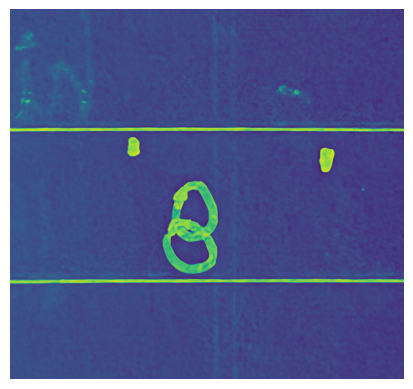

In [18]:
predict_image('/content/8 img.jpeg')

In [21]:
def predict_image(image_path):
  img=Image.open(image_path).convert('L')
  img=ImageOps.invert(img)
  plt.imshow(img)
  plt.axis('off')
  plt.show()
  img=img.resize((28,28))
  img_array=np.array(img)
  img_array=img_array.astype('float32')/255.0 # Corrected 'tf.float32' to 'float32'
  img_array=img_array.reshape((1,28,28,1))

  prediction=model.predict(img_array)
  predicted_class=np.argmax(prediction)
  confidence=np.max(prediction)
  return predicted_class,confidence

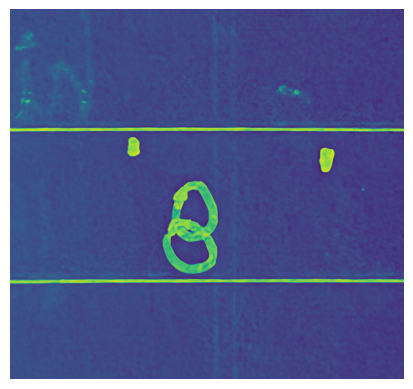

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


(np.int64(8), np.float32(0.98138064))

In [22]:
predict_image('/content/8 img.jpeg')

#MODEL ACCURACY

In [23]:
test_loss,test_acc=model.evaluate(test_images,test_labels_categorical)
print(f"test_loss:{test_loss}")
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5512 - loss: 1.3570
test_loss:1.3569788932800293
test_acc: 0.5511999726295471
